# Assigment: Research Other Visulizations for clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_pg = sns.load_dataset('penguins', cache=True, data_home=None)
df_pg.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
#select varibles for plotting
df_select = df_pg[['flipper_length_mm', 'bill_length_mm', 'species']]

#remove missing values
df_select.dropna(inplace=True)

#sclae the values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_std = pd.DataFrame(scaler.fit_transform(df_select.iloc[:,0:2]),
                      columns=['flipper', 'bill_length'])
df_std.head()

C:\Users\clayton jhordan\AppData\Local\Temp\ipykernel_23948\3193680210.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select.dropna(inplace=True)


,flipper,bill_length
0,-1.418347,-0.884499
1,-1.062250,-0.811126
2,-0.421277,-0.664380
3,-0.563715,-1.324737
4,-0.777373,-0.847812


# Scatter Plot

In [4]:
color_dict = {'Adelie':'#F65E5D',
              'Chinstrap':'#3AB4F2',
              'Gentoo':'#FFBC46'}

In [10]:
label_dict = {0:'Adelie', 1:'Chinstrap', 2:'Gentoo'}

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, max_iter=1000).fit(df_std[['flipper',
                                                                        'bill_length']])
df_std['cluster'] = kmeans.labels_
df_std['species_'] = [label_dict.get(i) for i in df_std.cluster]
df_std

,flipper,bill_length,cluster,species_
0,-1.418347,-0.884499,1,Chinstrap
1,-1.062250,-0.811126,1,Chinstrap
2,-0.421277,-0.664380,1,Chinstrap
3,-0.563715,-1.324737,1,Chinstrap
4,-0.777373,-0.847812,1,Chinstrap
...,...,...,...,...
337,0.931890,0.601305,0,Adelie
338,1.003109,0.527932,0,Adelie
339,1.501644,1.188289,0,Adelie
340,0.789451,0.234440,0,Adelie


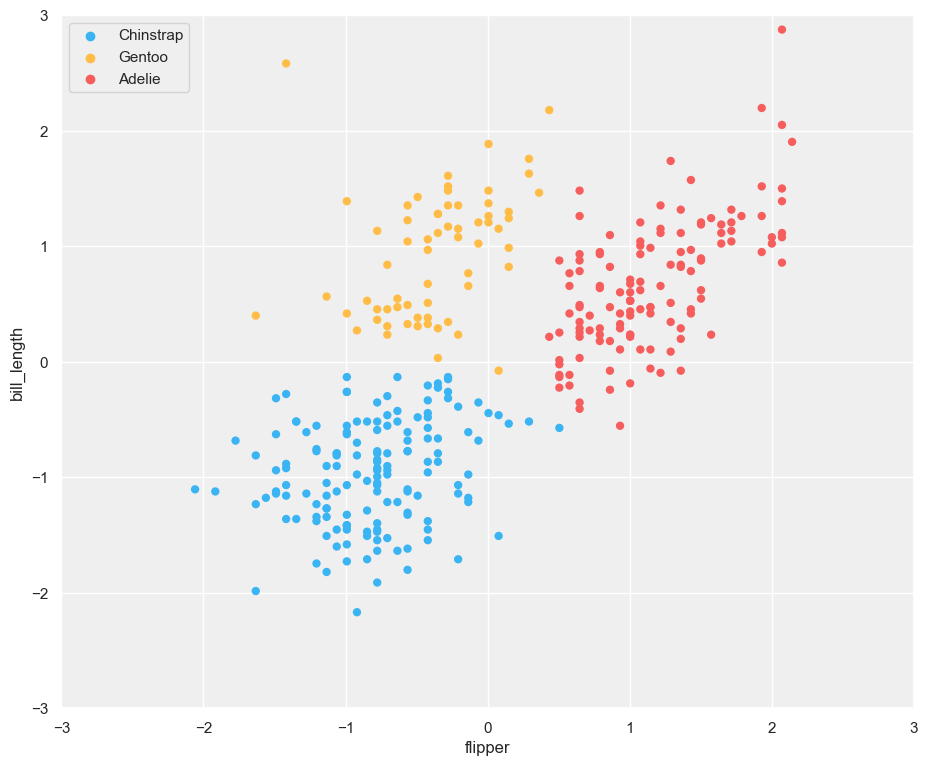

In [11]:
sns.set(rc={'axes.facecolor':'EFEFEF'})
ax = plt.figure(figsize=(11,9))
ax = sns.scatterplot(data=df_std, x = 'flipper', y ='bill_length',
                     hue='species_',
                     palette=color_dict,
                     s=36, linewidth=0)
plt.legend(loc='upper left')
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.savefig('scatter.png')
plt.show()

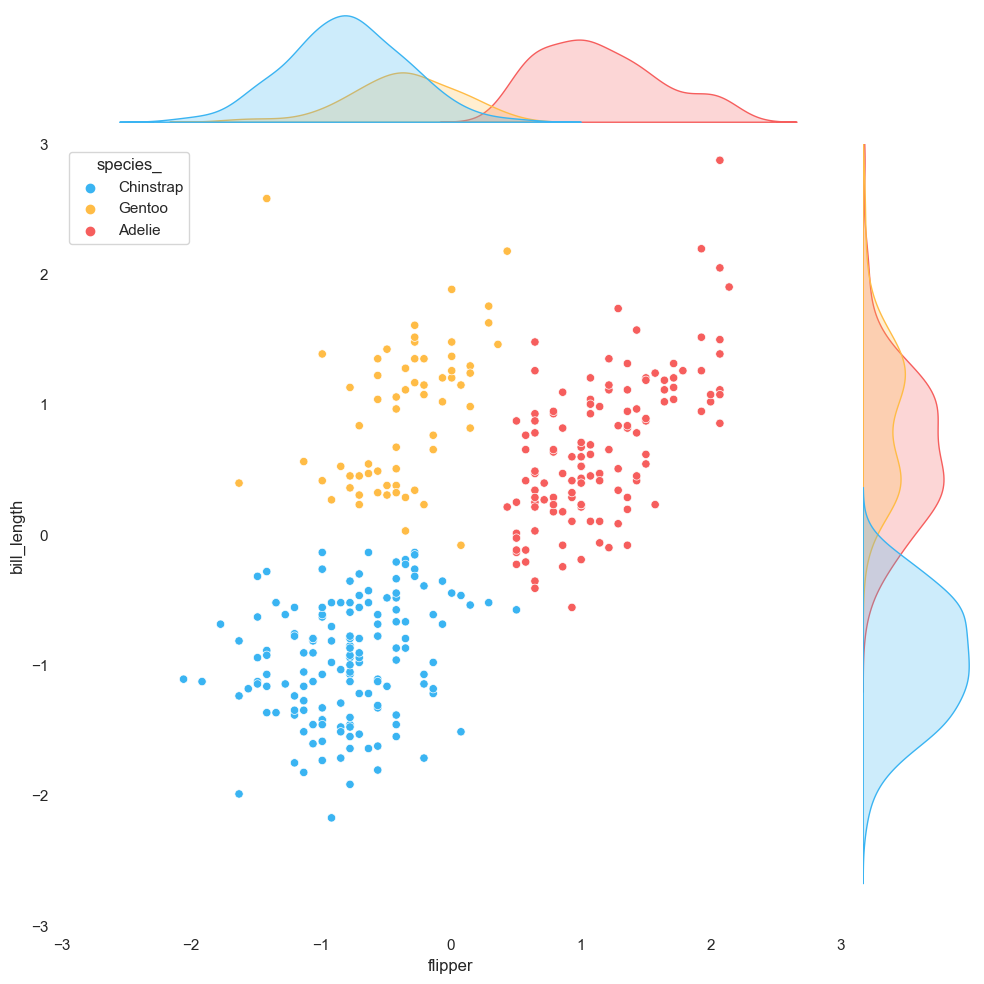

In [14]:
### scatter plot with marginal axes
sns.set_style('white')
sns.jointplot(x=df_std.flipper, y=df_std.bill_length,
              hue=df_std.species_, palette=color_dict,
              xlim=[-3,3], ylim=[-3,3], lw=0,
              height=10, ratio=6
             )
ax = sns.despine(ax=None, left=True, bottom=True)
plt.savefig('j_scatter_tr.png', transparent=True)
plt.show()

# KDE plot

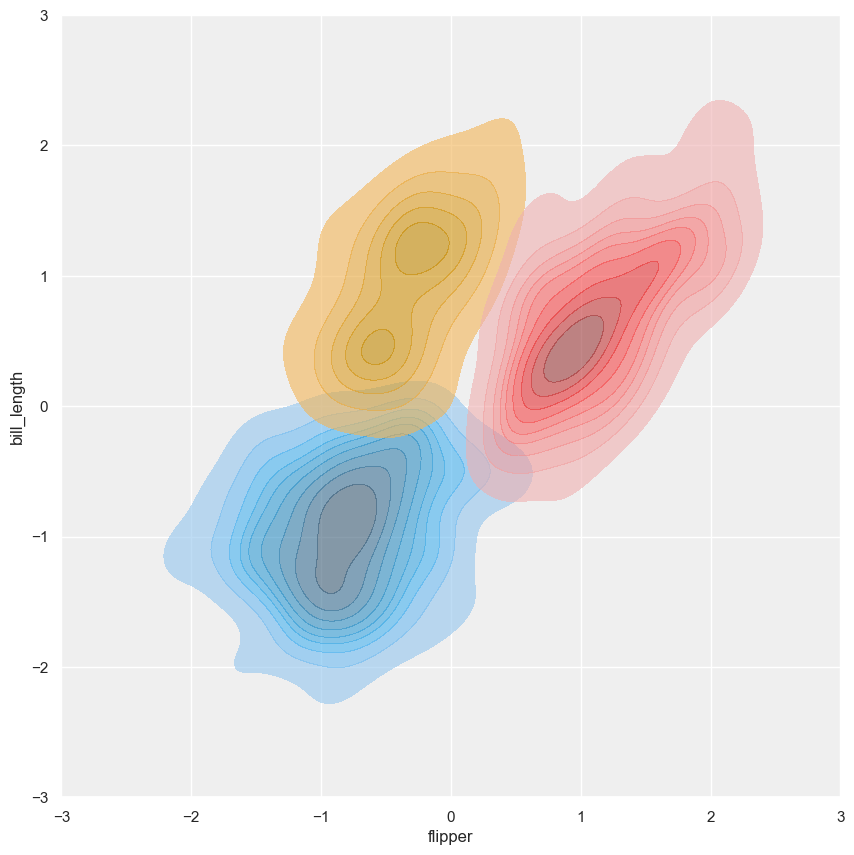

In [18]:
#create color list set a different tone of color from the data points 
color_dict_bg = {'Adelie':'#F65C5D', 'Chinstrap':'#3AB2F2', 'Gentoo':'#FFBA46'}

### kde plot
sns.set(rc={'axes.facecolor':'EFEFEF'})
ax = sns.jointplot(x=df_std.flipper, y=df_std.bill_length,
              cut = 2, hue=df_std.species_,
              palette=color_dict_bg,
              xlim=[-3,3], ylim=[-3,3],
              kind='kde', fill=True,
              height=10, ratio=6,
              joint_kws = dict(alpha=0.6),
              marginal_kws=dict(fill=True),
              legend=False)
ax.ax_marg_x.remove()
ax.ax_marg_y.remove()
# plt.savefig('kde.png')
plt.show()

# Line plot

In [20]:
x_avg = df_std['flipper'].mean()
y_avg = df_std['bill_length'].mean()
centroids = [list(i) for i in list(kmeans.cluster_centers_)]
centroids

[[1.1477907585857148, 0.6665893202302959],
 [-0.8085020383937745, -0.9582361857580423],
 [-0.37008778973321976, 0.938075318440887]]

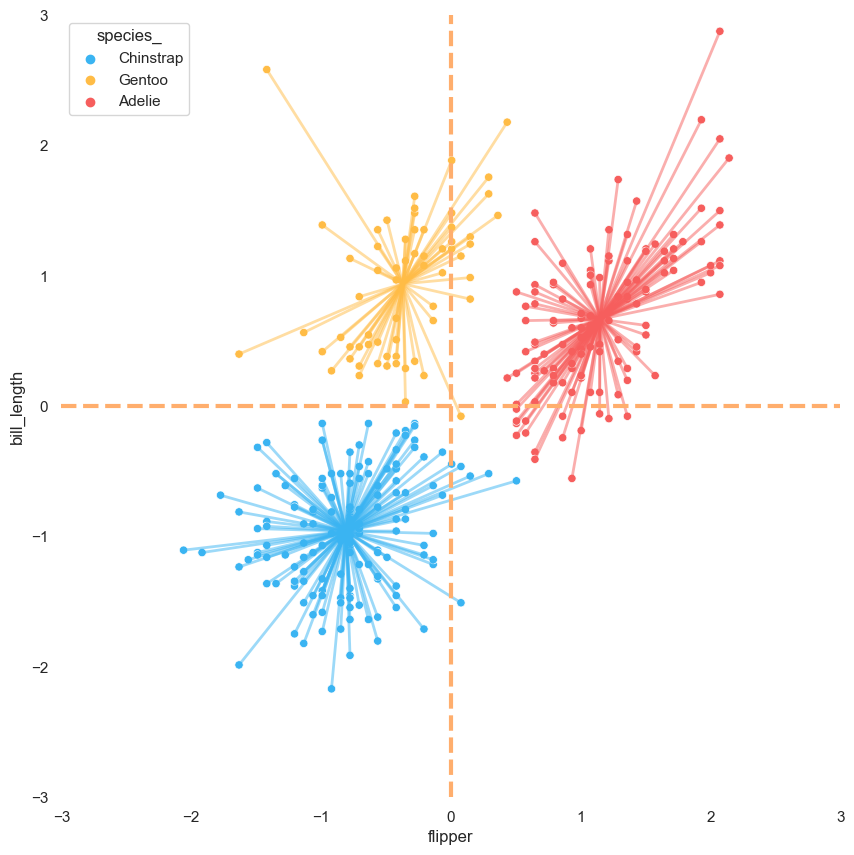

In [21]:
list_penguins = ['Adelie', 'Chinstrap', 'Gentoo']

###with marginal axes
ax = sns.jointplot(x=df_std.flipper, y=df_std.bill_length,
              hue=df_std.species_,
              palette=color_dict,
              xlim=[-3,3], ylim=[-3,3], lw=0,
              height=10, ratio=6
             )
for i,p in zip(centroids,list_penguins):
    df = df_std[df_std.species_==p]
    for pc1, pc2 in zip(df.flipper, df.bill_length):
        color = color_dict.get(p)
        ax.ax_joint.plot([i[0],pc1],[i[1],pc2], lw=2,
                         color=color, alpha=0.5,
                        )
#add avagare line
ax.ax_joint.axvline(x=x_avg, lw=3, c='#FFAE6D', ls='--')
ax.ax_joint.axhline(y=y_avg, lw=3, c='#FFAE6D', ls='--')
#remove marginal axes
ax.ax_marg_x.remove()
ax.ax_marg_y.remove()
ax = sns.despine(ax=None, top=True, right=True, left=True,
                 bottom=True, offset=None, trim=False)

# plt.savefig('line_tr.png', transparent=True)
plt.show()



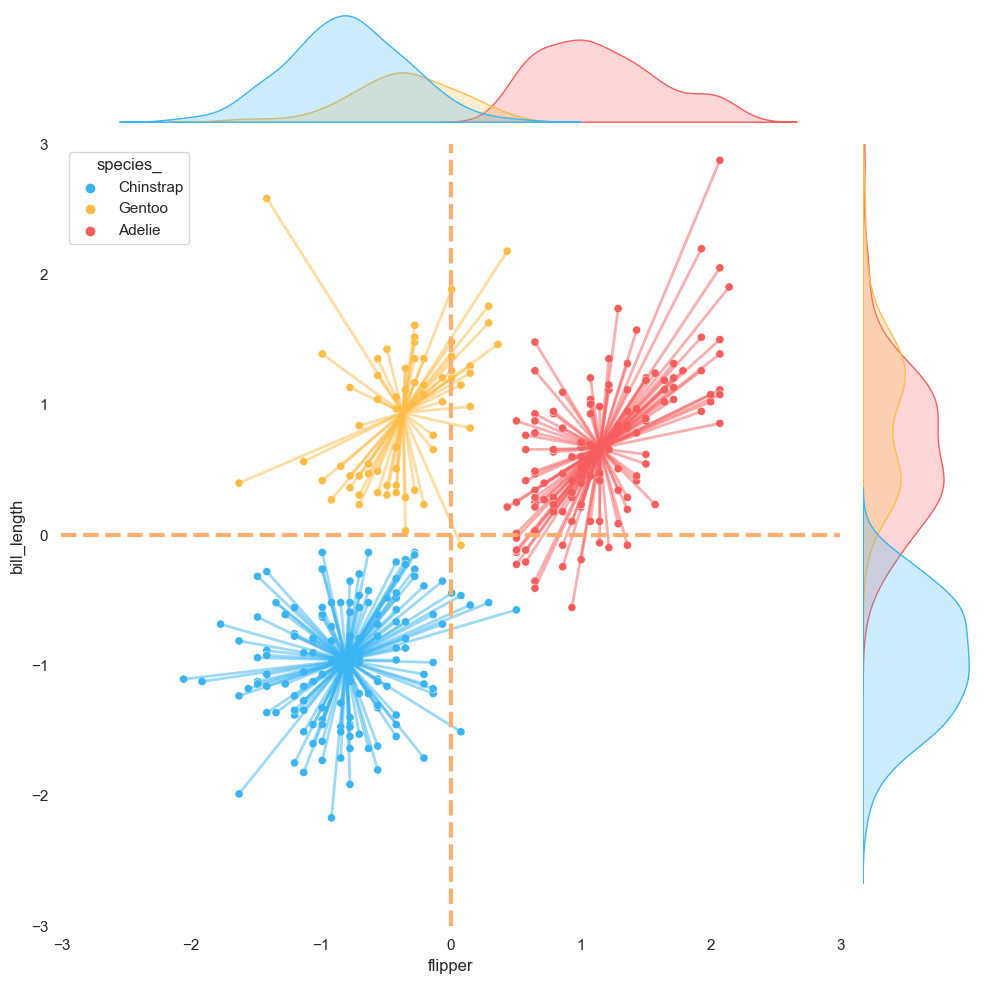

In [22]:

####with marginal axes
ax = sns.jointplot(x=df_std.flipper, y=df_std.bill_length,
              hue=df_std.species_,
              palette=color_dict,
              xlim=[-3,3], ylim=[-3,3], lw=0,
              height=10, ratio=6
             )
for i,p in zip(centroids,list_penguins):
    df = df_std[df_std.species_==p]
    for pc1, pc2 in zip(df.flipper, df.bill_length):
        color = color_dict.get(p)
        ax.ax_joint.plot([i[0],pc1],[i[1],pc2], lw=2,
                         color=color, alpha=0.5,
                        )
# add avagare line
ax.ax_joint.axvline(x=x_avg, lw=3, c='#FFAE6D', ls='--')
ax.ax_joint.axhline(y=y_avg, lw=3, c='#FFAE6D', ls='--')
ax = sns.despine(ax=None, left=True, bottom=True)

# plt.savefig('j_line_tr.png', transparent=True)
plt.show()

# Regression plot

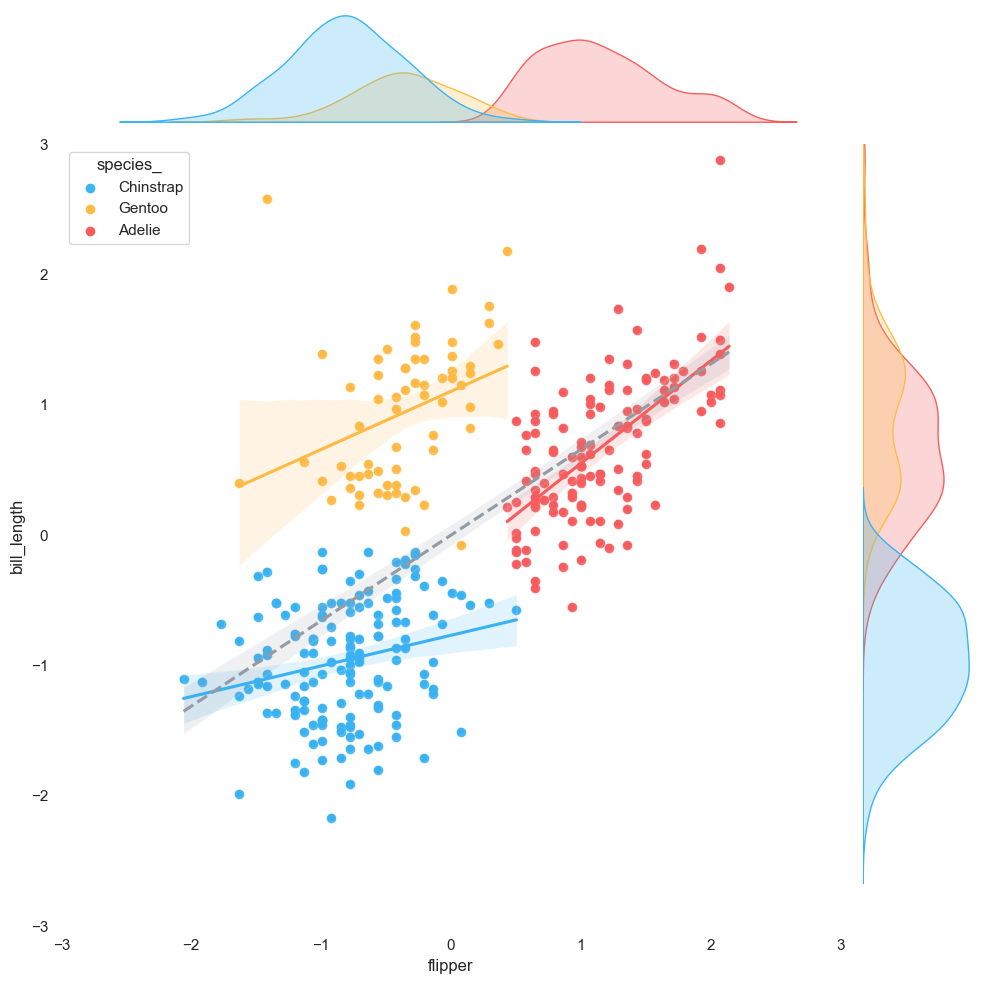

In [23]:

####with marginal axes
ax = sns.jointplot(x=df_std.flipper, y=df_std.bill_length,
              hue=df_std.species_, palette=color_dict,
              xlim=[-3,3], ylim=[-3,3], lw=0,
              height=10, ratio=6
             )
for p in list_penguins:
    df = df_std[df_std.species_==p]
    sns.regplot(x=df.flipper, y=df.bill_length,
                color=color_dict_bg.get(p), ax=ax.ax_joint)
    
sns.regplot(x=df_std.flipper, y=df_std.bill_length,
            color='#949ba4', ax=ax.ax_joint, scatter=False, line_kws={'linestyle': '--'})
ax = sns.despine(ax=None, top=True, right=True, left=True,
                 bottom=True, offset=None, trim=False)
# plt.savefig('j_reg.png', transparent=True)
plt.show()